In [ ]:
print("project started")

In [ ]:
import pandas as pd

df = pd.read_csv("../data/Dataset.csv")

df.head()

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

In [ ]:
df.info()

In [ ]:
df.duplicated().sum()

In [ ]:
df.head(10)

In [ ]:
df.groupby('Category')['Purchase Amount (USD)'].sum()

In [ ]:
df['Discount Applied'].value_counts()

In [ ]:
df.groupby('Category')['Purchase Amount (USD)'].mean()

In [ ]:
df['Frequency of Purchases'].value_counts()

In [ ]:
freq_map = {
  'Weekly': 52,
  'Fortnightly': 26,
  'Monthly': 12,
  'Quarterly': 4,
  'Annually': 1
}

df['annual_frequency'] = df['Frequency of Purchases'].map(freq_map)

df[['Frequency of Purchases', 'annual_frequency']].head()

In [ ]:
df['Discount Applied'] = df['Discount Applied'].map({
    'Yes': 1,
    'No': 0
})

df['Promo Code Used'] = df['Promo Code Used'].map({
    'Yes': 1,
    'No': 0
})

df[['Discount Applied', 'Promo Code Used']].head()

In [ ]:
df['promo_dependency'] = (
    0.6 * df['Discount Applied'] +
    0.4 * df['Promo Code Used']
)

df[['Discount Applied',
    'Promo Code Used',
    'promo_dependency']].head(10)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_columns = scaler.fit_transform(
    df[['Purchase Amount (USD)',
        'Previous Purchases',
        'annual_frequency',
        'Review Rating']]
)

scaled_df = pd.DataFrame(
    scaled_columns,
    columns=[
        'purchase_scaled',
        'previous_scaled',
        'frequency_scaled',
        'review_scaled'
    ]
)

scaled_df.head()

In [ ]:
df = pd.concat([df, scaled_df], axis=1)

df['loyalty_score'] = (
    0.4 * df['previous_scaled'] +
    0.3 * df['frequency_scaled'] +
    0.2 * df['purchase_scaled'] +
    0.1 * df['review_scaled']
)

df[['loyalty_score']].head(10)

In [ ]:
def customer_tier(x):
    if x >= 0.75:
        return 'High Value'
    elif x >= 0.45:
        return 'Medium Value'
    else:
        return 'Low Value'

df['value_tier'] = df['loyalty_score'].apply(customer_tier)

df[['loyalty_score', 'value_tier']].head(10)

In [ ]:
df['value_tier'].value_counts()

In [ ]:
df.groupby('value_tier')[
    ['loyalty_score', 'promo_dependency']
].mean()

In [ ]:
df.groupby('Category')['loyalty_score'].mean()

In [ ]:
import matplotlib.pyplot as plt

df['value_tier'].value_counts().plot(kind='bar')

plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.show()

In [ ]:
segment_data = df.groupby('value_tier')[
    ['loyalty_score', 'promo_dependency']
].mean()

segment_data.plot(kind='bar')

plt.title('Loyalty vs Promo Dependency')
plt.ylabel('Average Score')

plt.show()

In [ ]:
df.to_csv(
    '../data/customer_features.csv',
    index=False
)

In [ ]:
import sqlite3

conn = sqlite3.connect('../customer.db')

df.to_sql(
    'customers',
    conn,
    if_exists='replace',
    index=False
)

print("Data imported successfully")

In [1]:
import pandas as pd

df = pd.read_csv("../data/Dataset.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


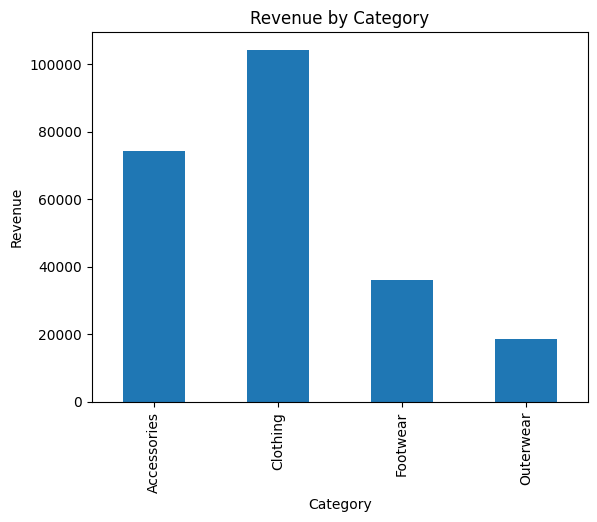

In [2]:
import matplotlib.pyplot as plt

category_revenue = df.groupby('Category')['Purchase Amount (USD)'].sum()

category_revenue.plot(kind='bar')

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.show()